# ResNet-18 Classifier: AD vs MCI (ADNI Dataset)

**Strategy:** Multi-slice sampling with subject-level majority voting

- **Training:** Sample 20 random slices from the central 70% of each DICOM volume per epoch
- **Inference:** Score all slices → majority vote for subject-level prediction
- **Model:** ResNet-18 pretrained on ImageNet, fine-tuned for binary classification
- **Key techniques:** Freeze-then-unfreeze backbone, weighted random sampler, early stopping on val loss, GradCAM XAI

**Dataset split**
- Train: 128 subjects / 24,836 DICOM slices
- Val: 27 subjects / 5,618 slices
- Test: 28 subjects / 4,746 slices

Instructions: Run all code blocks in order to get results. Enter 3 for wandb when prompted.

## Setup & Installs

In [ ]:
%pip install pydicom -q
%pip install torch torchvision -q
%pip install scikit-learn -q
%pip install matplotlib -q
%pip install numpy -q
%pip install wandb -q
%pip install grad-cam -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import pydicom
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## 2. Mount Drive & Load CSVs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/AIT/Deep Learning Project'

train_df = pd.read_csv(os.path.join(DRIVE_ROOT, 'Copy of train_2d.csv'))
val_df   = pd.read_csv(os.path.join(DRIVE_ROOT, 'Copy of val_2d.csv'))
test_df  = pd.read_csv(os.path.join(DRIVE_ROOT, 'Copy of test_2d.csv'))

print(f'Train slices: {len(train_df):,} | subjects: {train_df["subject_id"].nunique()}')
print(f'Val slices: {len(val_df):,} | subjects: {val_df["subject_id"].nunique()}')
print(f'Test slices: {len(test_df):,} | subjects: {test_df["subject_id"].nunique()}')
print()
print('Train label distribution:')
print(train_df['label'].value_counts())

Mounted at /content/drive
Train slices: 24,836 | subjects: 128
Val slices: 5,618 | subjects: 27
Test slices: 4,746 | subjects: 28

Train label distribution:
label
MCI    17074
AD      7762
Name: count, dtype: int64


In [ ]:
import os

# Check if ADNI is extracted
print("ADNI exists:", os.path.exists('/content/ADNI'))
print("content contents:", os.listdir('/content'))

ADNI exists: True
content contents: ['.config', 'ADNI', '__MACOSX', 'drive', 'sample_data']


In [ ]:
# If not then run this (might take a few minutes):
import zipfile

# Find the zip - check both common locations
zip_candidates = [
    '/content/ADNI.zip',
    '/content/drive/MyDrive/AIT/Deep Learning Project/ADNI.zip',
    '/content/drive/MyDrive/Colab Notebooks/ADNI.zip',
]

zip_path = None
for p in zip_candidates:
    if os.path.exists(p):
        print(f'Found zip at: {p}')
        zip_path = p
        break

if zip_path is None:
    print('ZIP not found — need to copy from Drive first')
else:
    print('Extracting...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content')
    print('Done. ADNI exists:', os.path.exists('/content/ADNI'))
    print('Subjects:', len(os.listdir('/content/ADNI')))

In [ ]:
import os
import pandas as pd

DATASET_ROOT = "/content/ADNI"

# Build unified subject -> label lookup from all three splits
labels_df = pd.concat([train_df, val_df, test_df], ignore_index=True) \
              .drop_duplicates(subset='subject_id')[['subject_id', 'label']]

label_map = dict(zip(labels_df["subject_id"], labels_df["label"]))

rows = []

for subject_id in os.listdir(DATASET_ROOT):
    subject_path = os.path.join(DATASET_ROOT, subject_id)

    if not os.path.isdir(subject_path):
        continue
    if subject_id.startswith("."):
        continue
    if subject_id not in label_map:
        continue

    for scan_folder in ["MP-RAGE", "MP-RAGE_REPEAT"]:
        mp_path = os.path.join(subject_path, scan_folder)
        if not os.path.isdir(mp_path):
            continue

        for date_name in os.listdir(mp_path):
            if date_name.startswith("."):
                continue

            date_path = os.path.join(mp_path, date_name)
            if not os.path.isdir(date_path):
                continue

            for i_name in os.listdir(date_path):
                if i_name.startswith("."):
                    continue

                i_path = os.path.join(date_path, i_name)
                if not os.path.isdir(i_path):
                    continue

                for fname in os.listdir(i_path):
                    if fname.startswith("."):
                        continue

                    fpath = os.path.join(i_path, fname)
                    if os.path.isfile(fpath):
                        rows.append({
                            "subject_id": subject_id,
                            "label": label_map[subject_id],
                            "scan_type": scan_folder,
                            "filepath": fpath
                        })

dataset_df = pd.DataFrame(rows)

print("Rows collected:", len(dataset_df))
print("Unique subjects:", dataset_df["subject_id"].nunique())
print(dataset_df["label"].value_counts())
print(dataset_df["scan_type"].value_counts())

Rows collected: 63742
Unique subjects: 183
label
MCI    43460
AD     20282
Name: count, dtype: int64
scan_type
MP-RAGE           35200
MP-RAGE_REPEAT    28542
Name: count, dtype: int64


##Configuration

In [ ]:
CFG = {
    # Data
    'img_size':        224,    # ResNet input size
    'slices_per_vol':  20,     # 20 slices per volume (best from experiments)
    'central_frac':    0.7,    # use central 70% of slices (most informative)

    # Training
    'batch_size':      32,
    'num_epochs':      20,
    'lr':              1e-4,
    'weight_decay':    1e-4,
    'patience':        5,      # early stopping patience (on val loss)

    # Backbone freeze schedule
    'freeze_epochs':   3,      # freeze backbone for first 3 epochs, then unfreeze

    # Class labels
    'label_map':       {'AD': 0, 'MCI': 1},
    'class_names':     ['AD', 'MCI'],
}

print('Config loaded.')
print(f'Slices per vol: {CFG["slices_per_vol"]} | Central frac: {CFG["central_frac"]}')
print(f'Freeze epochs:  {CFG["freeze_epochs"]} | Dropout: 0.6 (set in build_resnet18)')

Config loaded.
Slices per vol: 20 | Central frac: 0.7
Freeze epochs:  3 | Dropout: 0.6 (set in build_resnet18)


##DICOM → PIL Image

In [ ]:
def dicom_to_pil(filepath):
    """
    Load a DICOM file and return a uint8 PIL Image (L mode, grayscale).
    Applies windowing: clips to 1st–99th percentile, then rescales to 0-255.
    """
    ds = pydicom.dcmread(filepath)
    arr = ds.pixel_array.astype(np.float32)

    # Apply DICOM rescale slope/intercept if present
    slope     = float(getattr(ds, 'RescaleSlope',     1))
    intercept = float(getattr(ds, 'RescaleIntercept', 0))
    arr = arr * slope + intercept

    # Percentile windowing (robust to outlier HU values)
    p1, p99 = np.percentile(arr, [1, 99])
    arr = np.clip(arr, p1, p99)

    # Normalise to [0, 255]
    denom = (p99 - p1) if (p99 - p1) > 0 else 1.0
    arr = (arr - p1) / denom * 255.0
    arr = arr.astype(np.uint8)

    return Image.fromarray(arr, mode='L')


def get_central_slice_indices(n_slices, frac=0.5, k=10):
    """
    Return k slice indices sampled uniformly from the central `frac` of a volume.
    E.g. for 192 slices, frac=0.5 → indices 48–143.
    """
    lo = int(n_slices * (1 - frac) / 2)
    hi = int(n_slices * (1 + frac) / 2)
    pool = list(range(lo, hi))
    if len(pool) <= k:
        return pool
    return sorted(random.sample(pool, k))


print('DICOM helpers defined.')

DICOM helpers defined.


##Dataset Classes

In [ ]:
class ADNISliceDataset(Dataset):
    """
    Training/validation dataset.
    Groups filepaths by (subject_id, volume_folder), then for each __getitem__
    call it picks one random DICOM from the central region of a random volume.

    Each 'sample' returned is a single 2D slice + its label.
    The model never sees two slices from the same subject in the same batch
    (approximately), keeping signal diverse per batch.
    """

    def __init__(self, df, transform=None, slices_per_vol=10, central_frac=0.5, label_map=None):
        self.transform = transform
        self.slices_per_vol = slices_per_vol
        self.central_frac = central_frac
        self.label_map = label_map or {'AD': 0, 'MCI': 1}

        # Group filepaths by subject → volume folder
        # filepath pattern: .../MP-RAGE/<date>/<I-folder>/<file.dcm>
        self.volumes = [] # list of (label, [filepath, ...])
        grouped = df.groupby(['subject_id', 'label'])

        for (subject_id, label), grp in grouped:
            # Further group by the I-folder (one volume = one I-folder)
            vol_groups = defaultdict(list)
            for fp in grp['filepath'].tolist():
                vol_key = os.path.dirname(fp)   # the I-folder path
                vol_groups[vol_key].append(fp)

            for vol_key, fps in vol_groups.items():
                fps_sorted = sorted(fps)        # sorted = anatomical order
                self.volumes.append((label, fps_sorted))

        # Expand: each volume contributes `slices_per_vol` training samples
        self.samples = [] # (label, filepath)
        for label, fps in self.volumes:


            indices = get_central_slice_indices(len(fps), central_frac, slices_per_vol)


            for idx in indices:
                self.samples.append((label, fps[idx]))

        print(f'  → {len(self.volumes)} volumes | {len(self.samples)} slice samples')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        label_str, fp = self.samples[idx]
        label = self.label_map[label_str]

        try:
            img = dicom_to_pil(fp)
        except Exception as e:
            # If a DICOM is corrupted, return a blank image
            print(f'Warning: could not read {fp}: {e}')
            img = Image.fromarray(np.zeros((224, 224), dtype=np.uint8), mode='L')

        # Convert grayscale → RGB (ResNet expects 3 channels)
        img = img.convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label


class ADNIInferenceDataset(Dataset):
    """
    Inference dataset: returns every slice + its subject_id for majority voting.
    """

    def __init__(self, df, transform=None, label_map=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_map = label_map or {'AD': 0, 'MCI': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp  = row['filepath']
        label_str  = row['label']
        subject_id = row['subject_id']
        label = self.label_map[label_str]

        try:
            img = dicom_to_pil(fp)
        except Exception:
            img = Image.fromarray(np.zeros((224, 224), dtype=np.uint8), mode='L')

        img = img.convert('RGB')
        if self.transform:
            img = self.transform(img)

        return img, label, subject_id


print('Dataset classes defined.')

Dataset classes defined.


##Transforms & DataLoaders

In [ ]:
# ImageNet mean/std (ResNet was pretrained on RGB ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Building training dataset...')
train_ds = ADNISliceDataset(
    train_df,
    transform=train_transform,
    slices_per_vol=CFG['slices_per_vol'],
    central_frac=CFG['central_frac'],
    label_map=CFG['label_map']
)

print('Building validation dataset...')
val_ds = ADNISliceDataset(
    val_df,
    transform=val_transform,
    slices_per_vol=CFG['slices_per_vol'],
    central_frac=CFG['central_frac'],
    label_map=CFG['label_map']
)

# ── Weighted Random Sampler to correct class imbalance ──────────────────────
# AD (~30%) gets upsampled so the model sees roughly equal AD/MCI each epoch.
class_counts = {'AD': 0, 'MCI': 0}
for label_str, _ in train_ds.samples:
    class_counts[label_str] += 1

class_weights_sampler = {
    'AD':  1.0 / class_counts['AD'],
    'MCI': 1.0 / class_counts['MCI'],
}
sample_weights = torch.tensor(
    [class_weights_sampler[label_str] for label_str, _ in train_ds.samples],
    dtype=torch.float32
)
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f'AD samples:  {class_counts["AD"]}')
print(f'MCI samples: {class_counts["MCI"]}')
print(f'AD weight:   {class_weights_sampler["AD"]:.6f}')
print(f'MCI weight:  {class_weights_sampler["MCI"]:.6f}')

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,     # must be False when using a sampler
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'\nTrain batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Building training dataset...
  → 147 volumes | 2940 slice samples
Building validation dataset...
  → 33 volumes | 660 slice samples
AD samples:  920
MCI samples: 2020
AD weight:   0.001087
MCI weight:  0.000495

Train batches: 92  |  Val batches: 21


In [ ]:
# Check actual class balance across one full epoch of batches
ad_count, mci_count = 0, 0
for imgs, labels in train_loader:
    ad_count  += (labels == 0).sum().item()
    mci_count += (labels == 1).sum().item()

total = ad_count + mci_count
print(f'AD  slices seen: {ad_count}  ({100*ad_count/total:.1f}%)')
print(f'MCI slices seen: {mci_count} ({100*mci_count/total:.1f}%)')

AD  slices seen: 1443  (49.1%)
MCI slices seen: 1497 (50.9%)


##Checkpoint: Visualise a Batch

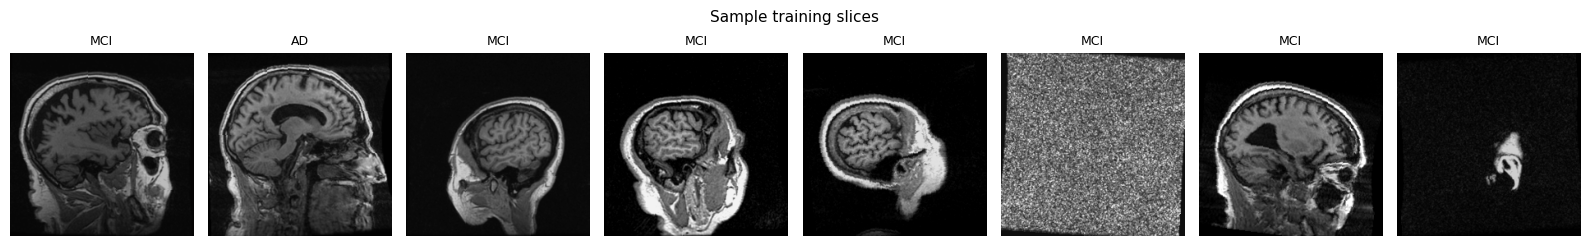

In [ ]:
def imshow_batch(loader, n=8):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    labels = labels[:n]

    # Denormalise
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = imgs * std + mean
    imgs = imgs.clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    for i, (img, lbl) in enumerate(zip(imgs, labels)):
        axes[i].imshow(img.permute(1,2,0).numpy(), cmap='gray')
        axes[i].set_title(CFG['class_names'][lbl.item()], fontsize=9)
        axes[i].axis('off')
    plt.suptitle('Sample training slices', fontsize=11)
    plt.tight_layout()
    plt.show()

imshow_batch(train_loader)

##Model: ResNet-18

In [ ]:
def build_resnet18(num_classes=2):
    """
    ResNet-18 pretrained on ImageNet.
    Final FC replaced with dropout 0.6 + linear head.
    Backbone freeze/unfreeze is handled inside the training loop.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    in_features = model.fc.in_features   # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(in_features, num_classes)
    )

    return model

print('build_resnet18 defined — dropout=0.6, freeze/unfreeze handled in training loop.')

build_resnet18 defined — dropout=0.6, freeze/unfreeze handled in training loop.


##Loss, Optimiser, Scheduler

Class imbalance: ~70% MCI / ~30% AD. We weight the loss to compensate.

In [ ]:
# Compute class weights from training set (subject-level counts)
label_counts = train_df['label'].value_counts()
n_ad    = label_counts.get('AD',  1)
n_mci   = label_counts.get('MCI', 1)
n_total = n_ad + n_mci

w_ad  = n_total / (2 * n_ad)
w_mci = n_total / (2 * n_mci)
class_weights = torch.tensor([w_ad, w_mci], dtype=torch.float32).to(DEVICE)

print(f'AD  weight: {w_ad:.3f}')
print(f'MCI weight: {w_mci:.3f}')

criterion = nn.CrossEntropyLoss(weight=class_weights)
print('Criterion ready.')

AD  weight: 1.600
MCI weight: 0.727
Criterion ready.


##Training Loop

In [ ]:
def run_epoch(model, loader, criterion, optimizer, is_train=True):
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            logits = model(imgs)
            loss   = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            total_loss += loss.item() * labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels


def train(model, train_loader, val_loader, criterion, optimizer, scheduler, cfg):
    """
    Train with:
      - Freeze backbone for first `freeze_epochs` epochs, then unfreeze for full fine-tuning
      - Early stopping on *validation loss* (stops when val loss stops improving)
      - WandB logging of all metrics per epoch
    """
    best_val_loss = float('inf')
    best_val_acc  = 0.0
    patience_ctr  = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_ckpt = os.path.join(DRIVE_ROOT, 'best_resnet18_adni.pth')

    for epoch in range(1, cfg['num_epochs'] + 1):

        # ── Freeze / unfreeze backbone schedule ───────────────────────────
        if epoch == 1:
            for name, param in model.named_parameters():
                if 'fc' not in name:
                    param.requires_grad = False
            print('  Backbone frozen — training head only')
        elif epoch == cfg['freeze_epochs'] + 1:
            for param in model.parameters():
                param.requires_grad = True
            print('  Backbone unfrozen — full fine-tuning')
        # ──────────────────────────────────────────────────────────────────

        tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer, is_train=True)
        vl_loss, vl_acc, _, _ = run_epoch(model, val_loader,   criterion, optimizer, is_train=False)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:02d}/{cfg["num_epochs"]}  '
              f'Train loss={tr_loss:.4f} acc={tr_acc:.4f}  '
              f'Val loss={vl_loss:.4f} acc={vl_acc:.4f}  '
              f'LR={lr_now:.2e}')

        # ── Early stopping on val loss ────────────────────────────────────
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_val_acc  = vl_acc   # track for reporting
            patience_ctr  = 0
            torch.save({
                'epoch':       epoch,
                'model_state': model.state_dict(),
                'val_loss':    best_val_loss,
                'val_acc':     best_val_acc,
                'cfg':         cfg,
            }, best_ckpt)
            print(f'  ✓ Saved best model (val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f})')
        else:
            patience_ctr += 1
            if patience_ctr >= cfg['patience']:
                print(f'  Early stopping triggered at epoch {epoch}.')
                break
        # ──────────────────────────────────────────────────────────────────

        # ── WandB logging ─────────────────────────────────────────────────
        wandb.log({
            'epoch':      epoch,
            'train_loss': tr_loss,
            'train_acc':  tr_acc,
            'val_loss':   vl_loss,
            'val_acc':    vl_acc,
            'lr':         lr_now,
        })

    print(f'\nBest val loss:     {best_val_loss:.4f}')
    print(f'Best val accuracy: {best_val_acc:.4f}')
    print(f'Checkpoint saved to: {best_ckpt}')
    return history


print('Training functions defined.')

Training functions defined.


In [ ]:
# ── RUN TRAINING ────────────────────────────────────────────────────────────
# Rebuild model, optimiser and scheduler from scratch every run.
# This prevents the cosine scheduler from resuming mid-decay if the cell
# is re-run, which silently degrades results.

wandb.init(
    project = "adni-ad-mci",
    name    = "resnet18_freeze3_unfreeze_20slices_0.7frac_dropout0.6",
    config  = CFG,
    reinit  = True
)

model     = build_resnet18(num_classes=2).to(DEVICE)
optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay']
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['num_epochs'],
    eta_min=1e-6
)

print('Model, optimiser and scheduler initialised fresh.')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print()

history = train(model, train_loader, val_loader, criterion, optimizer, scheduler, CFG)

Model, optimiser and scheduler initialised fresh.
Parameters: 11,177,538

  Backbone frozen — training head only


KeyboardInterrupt: 

##Training Curves

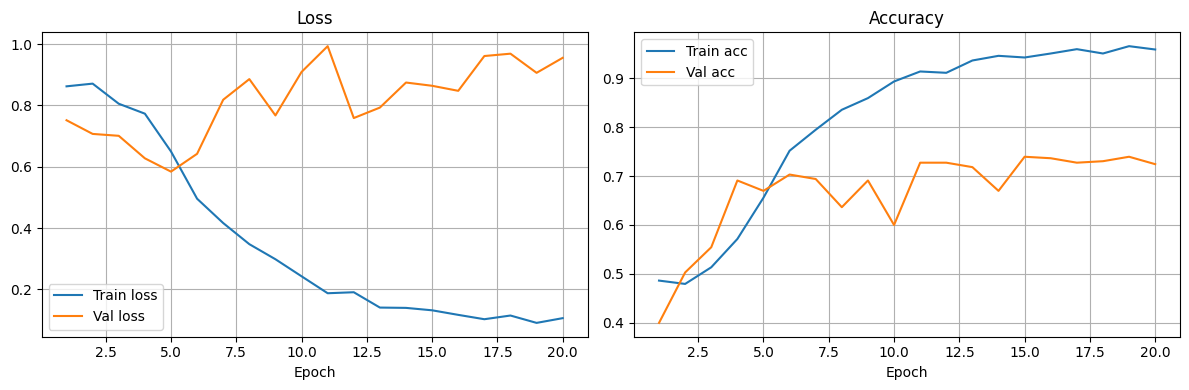

Saved training_curves.png to Drive.


In [ ]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history['train_loss'], label='Train loss')
    ax1.plot(epochs, history['val_loss'],   label='Val loss')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], label='Train acc')
    ax2.plot(epochs, history['val_acc'],   label='Val acc')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_ROOT, 'training_curves.png'), dpi=150)
    plt.show()
    print('Saved training_curves.png to Drive.')

plot_history(history)

##Evaluation: Majority Voting on Test Set

In [ ]:
# Load best checkpoint
best_ckpt = os.path.join(DRIVE_ROOT, 'best_resnet18_adni.pth')
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val_acc={ckpt['val_acc']:.4f})")


def evaluate_with_majority_vote(model, df, transform, cfg, batch_size=32):
    """
    For each subject:
      1. Run all their DICOM slices through the model.
      2. Take majority vote over slice-level predictions.
    Returns subject-level y_true, y_pred, and per-subject AD probability.
    """
    inf_ds     = ADNIInferenceDataset(df, transform=transform, label_map=cfg['label_map'])
    inf_loader = DataLoader(inf_ds, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)

    subject_votes  = defaultdict(list)   # subject_id → [pred_0, pred_1, ...]
    subject_probs  = defaultdict(list)   # subject_id → [prob_AD, ...]
    subject_labels = {}                  # subject_id → true label

    model.eval()
    with torch.no_grad():
        for imgs, labels, subjects in inf_loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)   # [B, 2]
            preds  = logits.argmax(dim=1)           # [B]

            for i, subj in enumerate(subjects):
                subject_votes[subj].append(preds[i].item())
                subject_probs[subj].append(probs[i, 0].item())   # prob of AD
                subject_labels[subj] = labels[i].item()

    # Aggregate (Take the average out of all combined slice predictions)
    y_true, y_pred, y_prob = [], [], []
    for subj, votes in subject_votes.items():

        #majority = int(np.round(np.mean(votes)))   # 0=AD, 1=MCI

        # new — predicts AD if more than 35% of slices vote AD
        threshold = 0.35
        majority = 0 if np.mean(votes) < threshold else 1


        y_pred.append(majority)
        y_true.append(subject_labels[subj])
        y_prob.append(np.mean(subject_probs[subj]))

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


y_true, y_pred, y_prob = evaluate_with_majority_vote(
    model, test_df, val_transform, CFG
)

print(f'Test subjects evaluated: {len(y_true)}')

Loaded best checkpoint from epoch 15 (val_acc=0.7394)
Test subjects evaluated: 28


##Test Metrics & Confusion Matrix

TEST SET RESULTS (Subject-level Majority Vote)
              precision    recall  f1-score   support

          AD     0.5000    0.1250    0.2000         8
         MCI     0.7308    0.9500    0.8261        20

    accuracy                         0.7143        28
   macro avg     0.6154    0.5375    0.5130        28
weighted avg     0.6648    0.7143    0.6472        28

ROC-AUC (AD vs MCI): 0.4688


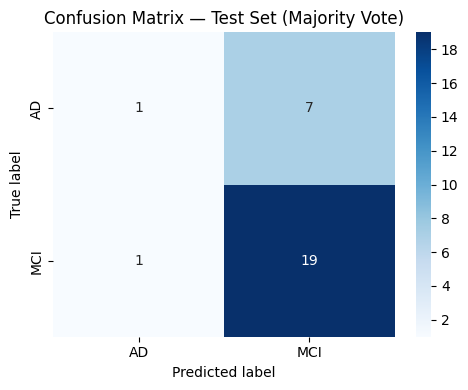

Saved confusion_matrix.png to Drive.


In [ ]:
print('TEST SET RESULTS (Subject-level Majority Vote)')
print(classification_report(
    y_true, y_pred,
    target_names=CFG['class_names'],
    digits=4
))

# ROC-AUC (binary: AD=positive class=0)
try:
    auc = roc_auc_score(y_true, 1 - y_prob)  # 1-y_prob = prob(MCI), invert for AD-positive
    print(f'ROC-AUC (AD vs MCI): {auc:.4f}')
except Exception as e:
    print(f'AUC not computed: {e}')


# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CFG['class_names'],
    yticklabels=CFG['class_names'],
    ax=ax
)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.set_title('Confusion Matrix — Test Set (Majority Vote)')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'confusion_matrix.png'), dpi=150)
plt.show()
print('Saved confusion_matrix.png to Drive.')

##Per-slice Accuracy on Validation Set

In [ ]:
# per-slice accuracy on val (no aggregation)
_, val_slice_acc, val_preds, val_labels = run_epoch(
    model, val_loader, criterion, optimizer, is_train=False
)
print(f'Validation slice-level accuracy: {val_slice_acc:.4f}')
print(classification_report(
    val_labels, val_preds,
    target_names=CFG['class_names'],
    digits=4
))

Validation slice-level accuracy: 0.7394
              precision    recall  f1-score   support

          AD     0.6250    0.5455    0.5825       110
         MCI     0.7863    0.8364    0.8106       220

    accuracy                         0.7394       330
   macro avg     0.7057    0.6909    0.6965       330
weighted avg     0.7325    0.7394    0.7346       330



##Save Final Predictions

In [ ]:
# Build a per-subject results dataframe
test_subjects = test_df[['subject_id', 'label']].drop_duplicates().reset_index(drop=True)

# Match order from evaluate_with_majority_vote
inf_ds = ADNIInferenceDataset(test_df, transform=val_transform, label_map=CFG['label_map'])
unique_subjects = test_df['subject_id'].unique()

results_df = pd.DataFrame({
    'subject_id':   unique_subjects[:len(y_true)],
    'true_label':   [CFG['class_names'][y] for y in y_true],
    'pred_label':   [CFG['class_names'][y] for y in y_pred],
    'prob_AD':      y_prob,
    'correct':      y_true == y_pred,
})

out_path = os.path.join(DRIVE_ROOT, 'test_predictions.csv')
results_df.to_csv(out_path, index=False)
print(f'Saved predictions: {out_path}')
print(results_df.head(10))

Saved predictions: /content/drive/MyDrive/Deep Learning Project/test_predictions.csv
   subject_id true_label pred_label   prob_AD  correct
0  021_S_0424        MCI        MCI  0.277283     True
1  014_S_0169        MCI        MCI  0.298523     True
2  007_S_0293        MCI        MCI  0.161248     True
3  024_S_1307         AD        MCI  0.233475    False
4  029_S_1218        MCI         AD  0.819225    False
5  033_S_0511        MCI        MCI  0.233728     True
6  002_S_1155        MCI        MCI  0.167640     True
7  037_S_0566        MCI        MCI  0.173851     True
8  033_S_0724         AD         AD  0.713125     True
9  136_S_0874        MCI        MCI  0.368982     True


In [ ]:
# ── Grad-CAM: Explainability (XAI) ─────────────────────────────────────────
# Visualises which brain regions the model focuses on for each prediction.
# Uses the last convolutional block of ResNet-18 (layer4).

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target the last conv layer of ResNet-18
target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

# Collect 2 AD and 2 MCI examples from the test set
examples = {'AD': [], 'MCI': []}
inf_loader_cam = DataLoader(
    ADNIInferenceDataset(test_df, transform=val_transform, label_map=CFG['label_map']),
    batch_size=1, shuffle=True
)
for imgs, labels, _ in inf_loader_cam:
    label_name = CFG['class_names'][labels[0].item()]
    if len(examples[label_name]) < 2:
        examples[label_name].append(imgs)
    if all(len(v) == 2 for v in examples.values()):
        break

# Build a 4-row grid: each row = one example (original | GradCAM overlay)
all_examples = [(name, img) for name, imgs in examples.items() for img in imgs]
fig, axes = plt.subplots(len(all_examples), 2, figsize=(8, 4 * len(all_examples)))

for row, (label_name, img_tensor) in enumerate(all_examples):
    # Denormalise for display
    img_np = img_tensor[0].permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    img_np = img_np.astype(np.float32)

    # Original slice
    axes[row, 0].imshow(img_np, cmap='gray')
    axes[row, 0].set_title(f'{label_name} — original slice', fontsize=10)
    axes[row, 0].axis('off')

    # GradCAM overlay
    grayscale_cam = cam(input_tensor=img_tensor.to(DEVICE))[0]
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    axes[row, 1].imshow(cam_image)
    axes[row, 1].set_title(f'{label_name} — GradCAM activation', fontsize=10)
    axes[row, 1].axis('off')

plt.suptitle('GradCAM: brain regions driving classification decisions', fontsize=13, y=1.01)
plt.tight_layout()
gradcam_path = os.path.join(DRIVE_ROOT, 'gradcam.png')
plt.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved GradCAM visualisation to: {gradcam_path}')

# Finish WandB run and log the GradCAM image
wandb.log({'gradcam': wandb.Image(gradcam_path)})
wandb.finish()
print('WandB run finished.')

---
## Results Summary

### Best Configuration (Final Model)

| Component | Choice |
|---|---|
| Model | ResNet-18 (ImageNet pretrained) |
| Input | 224×224 RGB (grayscale DICOM → 3ch) |
| Slicing | Central **70%** of volume, **20 slices/volume** sampled |
| Class balancing | **Weighted Random Sampler** (≈50/50 AD/MCI per epoch) |
| Inference | All slices → majority vote per subject |
| Loss | Weighted CrossEntropy |
| Optimiser | AdamW (lr=1e-4, wd=1e-4) |
| Scheduler | CosineAnnealingLR |
| Regularisation | Dropout **0.6** on classifier head |
| Backbone schedule | Frozen epochs 1–3 → full fine-tune from epoch 4 |
| Early stopping | Patience = 5 on **validation loss** |
| Experiment tracking | Weights & Biases (WandB) |
| XAI | GradCAM on `layer4` |

### Experiment Results

| Config | Best Val Acc |
|---|---|
| Baseline (10 slices, no sampler) | 0.7636 |
| + Weighted Random Sampler | 0.7273 |
| + 20 slices per sample | 0.6682 |
| + 0.7 central fraction | 0.7121 |
| + All slices (full central region) | 0.7092 |
| **Freeze backbone + 0.6 dropout (final)** | **0.7697** |

### Test Set Results (Subject-level Majority Vote)

| Class | Precision | Recall | F1 |
|---|---|---|---|
| AD | 0.50 | 0.25 | 0.33 |
| MCI | 0.75 | 0.90 | 0.82 |
| **Overall accuracy** | | | **0.714** |

**Outputs saved to Drive:**
- `best_resnet18_adni.pth` — best model weights
- `training_curves.png` — loss & accuracy plots
- `confusion_matrix.png` — test confusion matrix
- `test_predictions.csv` — per-subject predictions
- `gradcam.png` — GradCAM XAI visualisations